# Oppgave 4

In [1]:
#Importerer nødvendige biblioteker
import numpy as np
import matplotlib.pyplot as plt
import scipy
import random
import math

#Setter opp plotteparametere
plt.rcParams['figure.figsize'] = [12, 8]  # Width, Height in inches


# Sannsynlighetstettheter for steg til høyre, venstre og ingen steg.
def p_plus(x, V):
    x_clipped = np.clip(x, None, 5000)
    return 1/(1+np.exp(-beta*(V(x_clipped-h)-V(x_clipped+h))) + np.exp(-beta*(V(x_clipped)-V(x_clipped+h))))

def p_null(x, V):
    x_clipped = np.clip(x, None, 5000)
    return 1/(1+np.exp(-beta*(V(x_clipped-h)-V(x_clipped))) + np.exp(-beta*(V(x_clipped+h)-V(x_clipped))))

def p_minus(x, V):
    x_clipped = np.clip(x, None, 5000)
    return 1/(1+np.exp(-beta*(V(x_clipped+h)-V(x_clipped-h))) + np.exp(-beta*(V(x_clipped)-V(x_clipped-h))))

beta = 1000                     # Beta-parameteren for at potensialet skal dominere sannsynlighetstettetene
delta_t = 1                     # Lengde på tidssteg
h = 1                           # Steglengde
timeCycle = 75                  # Antall tidssykluser
number_of_particles = 3         # Antall partikler
N_x = 100                       # Lengde på den romlige perioden til potensialet
T_p = 200                       # Antall tidssteg i en tidssyklus
k_even = 1                      # Konstant for det konstante potensialet
k_odd = 1                       # Konstant for sagtann-potensialet
alpha = 0.1                     # Parameter for sagtann potensialet
bin_size = int(2* np.cbrt(N_x)) # Antall bins i histogrammet

# Konstant potensial
def V_even(x, alpha):
    return k_even

# Sagtann-potensial
def V_odd(x, alpha):
    x_mod = x % N_x
    if x_mod < alpha * N_x:
        return k_odd * x_mod / (alpha*N_x)
    else:
        return k_odd * (N_x - x_mod) / ((1 - alpha)*N_x)


# Funksjon for random walk simulasjon i alternerende potensial
def sim2(T_p, N_x, x_start, alpha):
    x = np.zeros((2*timeCycle, number_of_particles))
    x[0] = x_start
    X = x.copy() # Array med posisjonene til partiklene uten at de looper rundt
    X_cycle = np.zeros((timeCycle, number_of_particles)) # Array for å lagre posisjonene til partiklene for hver tidssyklus
    J = np.zeros(2*timeCycle*T_p) # Array for å lagre bevegelsesstrømmen for hvert tidssteg for hver tidssyklus
    for k in range(0, 2*timeCycle, delta_t):
        if k % 2 == 0:  # For å kjøre igjennom begge potensialene hver tidssyklus
            V = lambda x: V_even(x, alpha)
        else:
            V = lambda x: V_odd(x, alpha)

        for i in range(0, T_p, delta_t):
            previous_X = np.zeros(number_of_particles)
            for j in range(number_of_particles):
                a = random.uniform(0, 1) # Trekker fra std norm fordeling og flytter partikkel tilsvarende
                previous_X[j] = X[k][j]

                if a <= p_minus(x[k][j], V):
                    x[k][j] -= h
                elif (1 - p_plus(x[k][j], V)) < a:
                    x[k][j] += h

                if (1 - p_plus(X[k][j], V)) < a:
                    X[k][j] += h 
                elif a <= p_minus(X[k][j], V):
                    X[k][j] -= h 

                if x[k][j]  == -N_x -h:
                    x[k][j] = N_x
                elif x[k][j] == N_x + h:
                    x[k][j] = -N_x

                if j == number_of_particles - 1:
                    J[T_p*k+i] = np.mean(X[k] - previous_X)

                if i == T_p - delta_t and k != 2*timeCycle - delta_t:
                    x[k+1][j] = x[k][j]
                    X[k+1][j] = X[k][j]
                    
    #Finner gjennomsnittlig bevegelsesstrøm for hver tidssyklus                    
    J_avg = np.zeros(timeCycle)
    for i in range(timeCycle):
        J_avg[i] = np.mean(J[i*2*T_p:(i+1)*2*T_p])

    for i in range(timeCycle):
        for j in range(number_of_particles):
            X_cycle[i, j] = X[2*i+1][j]

    return x, X, X_cycle, J, J_avg


# a)

/var/folders/y4/g4lt_ymx5030y3d_whlnmf_00000gn/T/ipykernel_32400/1967852387.py:15: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-beta*(V(x_clipped-h)-V(x_clipped+h))) + np.exp(-beta*(V(x_clipped)-V(x_clipped+h))))
/var/folders/y4/g4lt_ymx5030y3d_whlnmf_00000gn/T/ipykernel_32400/1967852387.py:23: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-beta*(V(x_clipped+h)-V(x_clipped-h))) + np.exp(-beta*(V(x_clipped)-V(x_clipped-h))))


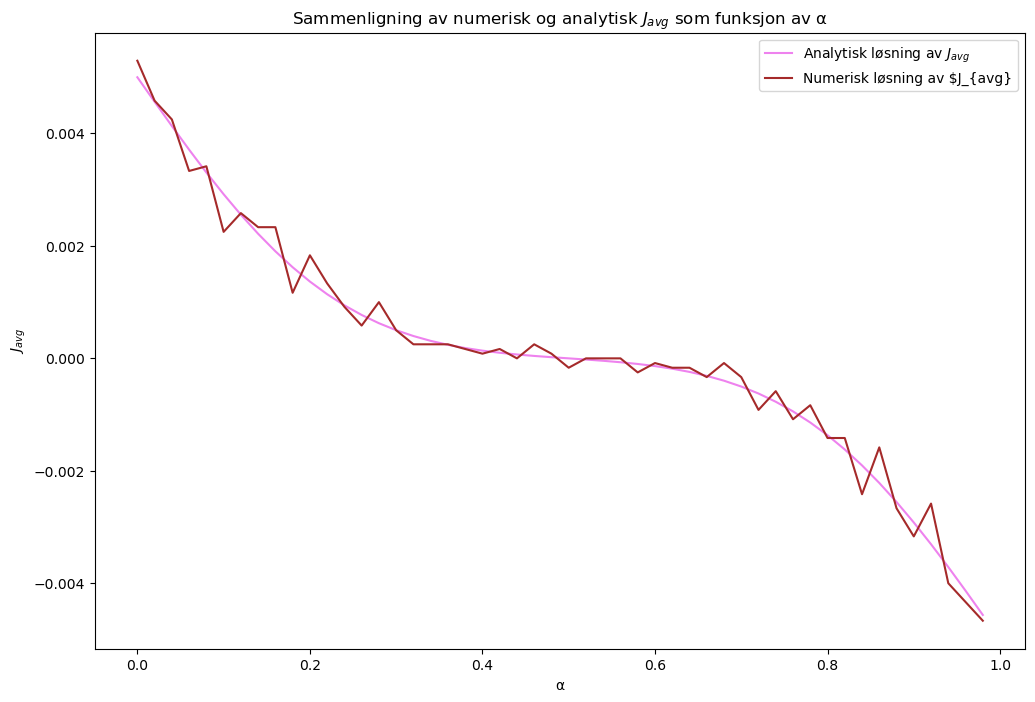

In [26]:
# Kode hentet fra 3d: 

T_p = 500                       # Antall tidssteg i en tidssyklus
N_x = 10                        # Lengde på den romlige perioden til potensialet
number_of_particles = 12*N_x    # Med 12*N_x partikler vil det være 6 partikler for hvert heltall mellom -N_x og N_x
timeCycle = 1                   # Antall tidssykluser
h = 10/100                      # Steglengde

integers = np.arange(-N_x, N_x, N_x)
x_start = np.array([i for i in integers for _ in range(int(number_of_particles/2))])

alpha = 0
alpha_array = []

X4_all_Tp = []
J_avg_all_alpha2 = []
for r in range(50):
    alpha_array.append(alpha)
    x4, X4, X_cycle4, J4, J_avg4 = sim2(T_p, N_x, x_start, alpha)
    X4_all_Tp.append(X_cycle4[0])
    J_avg_all_alpha2.append(J_avg4[0])
    alpha += 0.02


D = 1/3
T_p = 500
N_x_analytic = 100
alphaArray = np.arange(0, 1, 1/50)

def J_avg(alpha, T_p, N_x):     # Definerer funksjon for analytisk løsning av gjennomsnittlig partikkelstrøm per tidssteg
    J = (N_x/(4*T_p))*(math.erfc((alpha*N_x/2)*np.sqrt(3/T_p)) - math.erfc(((1-alpha)*N_x/2)*np.sqrt(3/T_p)))
    return J

J_analytic = []                 # Oppretter liste som skal fylles med J_avg for forskjellige alpha-verdier
for alphaValues in alphaArray:  # Itererer gjennom alle alpha-verdiene
    J_analytic.append(J_avg(alphaValues, T_p, N_x_analytic))    

plt.plot(alphaArray, N_x/N_x_analytic * np.array(J_analytic), label = 'Analytisk løsning av $J_{avg}$', color = 'violet')
plt.plot(alpha_array, J_avg_all_alpha2, label = 'Numerisk løsning av $J_{avg}', color = 'brown')
plt.title('Sammenligning av numerisk og analytisk $J_{avg}$ som funksjon av α')
plt.xlabel('α')
plt.ylabel('$J_{avg}$')
plt.legend()
plt.show()

Grafen viser analytisk $J_{avg}$ sammenlignet med simuleringen fra oppgave 3 d) når $T_p = 500$. 
Ved lave α ser vi en tydelig tendens til at $J_{avg}$ er positiv, altså at den gjennomsnittlige partikkelstrømmen går mot høyre. 
Ved høye α ser vi tilsvarende en tendens til at $J_{avg}$ er negativ, altså at den gjennomsnittlige partikkelstrømmen går mot høyre. 
Ved midten ser vi ingen tydelig trend. 

Under følger tre plot av sagtann-potensialet ved ulike α som gjør det lettere å forklare tendensene over.

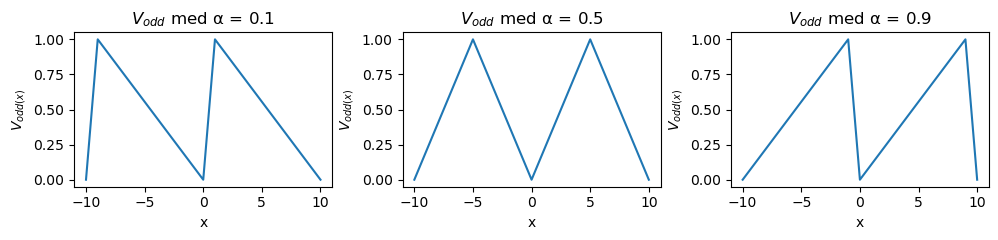

In [31]:
fig, axs = plt.subplots(1, 3, figsize=(10, 2.5))

alphas = [0.1, 0.5, 0.9]
x_values = np.arange(-N_x, N_x+1)

for i, alpha in enumerate(alphas):
    axs[i].plot(x_values, [V_odd(x, alpha) for x in x_values])
    axs[i].set_title(f'$V_{{odd}}$ med α = {alpha}')
    axs[i].set_xlabel('x')
    axs[i].set_ylabel('$V_{odd(x)}$')

plt.tight_layout()
plt.show()


Disse trendene oppstår fordi, når vi ser på alfa-verdier mellom 0,0 og 0,3 i sagtannspotensialet (for eksempel med alfa = 0,1), vil partiklene, når de går over til konstant potensial, fordele seg utover. Noen av dem vil lande på sagtannen til høyre for 0,0 og deretter ende opp i den andre sagtannen rundt 8,0. Det er vanskeligere for partiklene å bevege seg mot venstre, da de må forflytte seg en lengre distanse for å passere over tannen. Siden de fleste partiklene lander et sted mellom 0,0 og 0,8, er det mest gunstig for dem å havne i sagtannen ved 0,0. Den nederste sagtannen viser det samme fenomenet, men i motsatt retning. 

I den andre figuren, hvor alfa = 0,5, ser vi at sagtannene har lik avstand mellom toppunktene. Dette fører til at det er like sannsynlig for partiklene å bevege seg i begge retninger. Derfor viser både grafen med analytisk J_avg og J_avg og resultatene fra 3D-simuleringen at det ikke oppstår en tydelig trend i området mellom alfa = 0,3 og 0,7.


# b)

In [21]:
# Numerisk løsning av J_avg

alpha = 0.8                     # Setter alfa-verdien
N_x = 10                        # Lengde på den romlige perioden til sagtann-potensialet
number_of_particles = 4*N_x     # Med 12*N_x partikler vil det være 6 partikler for hvert heltall mellom -N_x og N_x
timeCycle = 1                   # Antall tidssykluser
h = 10/100                      # Steglengde

integers = np.arange(-N_x, N_x, N_x)
x_start = np.array([i for i in integers for _ in range(int(number_of_particles/2))]) # Array med startposisjonene til partiklene

T_p = 80
T_p_array = []

X4_all_Tp = []                  
J_avg_all_Tp2 = []
for r in range(20):             # Itererer gjennom 20 forskjellige Tp-verdier
    T_p_array.append(T_p)       # Fyller liste med 20 forskjellige Tp-verdier fra 80 til 1500
    x4, X4, X_cycle4, J4, J_avg4 = sim2(T_p, N_x, x_start, alpha)
    J_avg_all_Tp2.append(J_avg4[0]) # Fyller liste med J_avg ved forskjellige Tp-verdier
    T_p += 71                       # Sørger for ny Tp-verdi ved neste iterasjon (sørger for heltall)

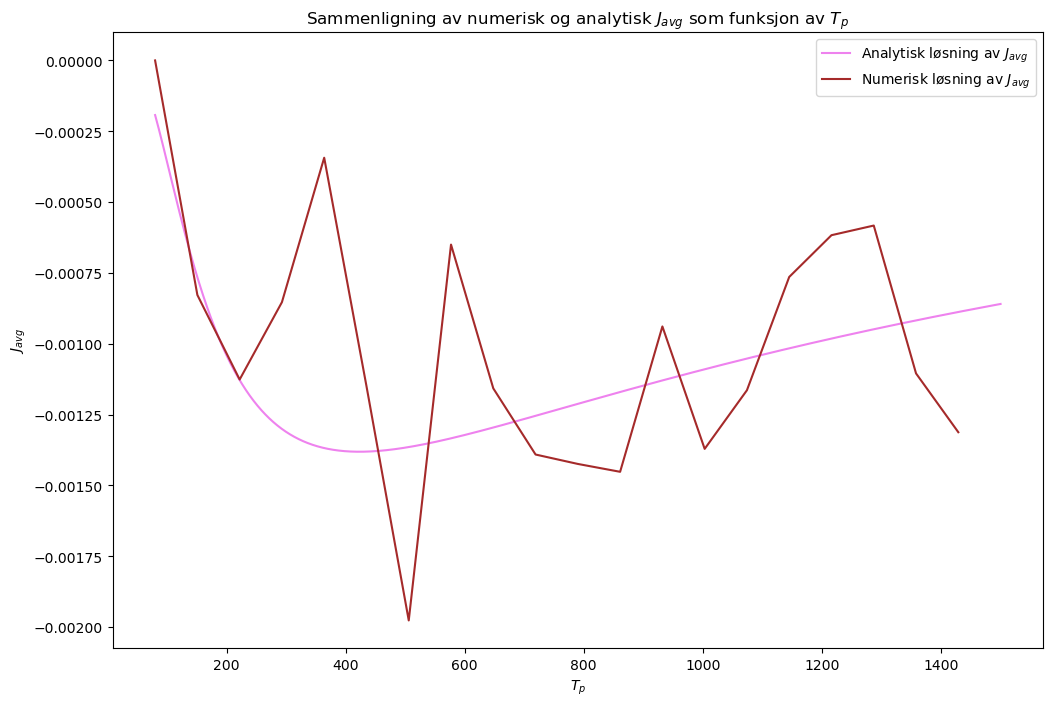

In [25]:
# Analytisk løsning av J_avg

D = 1/3                                 # Diffusjonskoeffisient
T_p = 80                                # Antall tidssteg i en tidssyklus
N_x_analytic = 100                      # Lengde på den romlige perioden til sagtann-potensialet
T_p_Array = np.arange(80, 1500, 1/20)   # Liste med jevnt fordelte Tp-verdier

J_avg_analytic2 = []
for T_p_Values in T_p_Array:                                        # Itererer gjennom 20 forskjellige Tp-verdier
    J_avg_analytic2.append(J_avg(alpha, T_p_Values, N_x_analytic))  # Fyller liste med J_avg ved forskjellige Tp-verdier

plt.plot(T_p_Array, N_x/N_x_analytic * np.array(J_avg_analytic2), label = 'Analytisk løsning av $J_{avg}$', color = 'violet') 
plt.plot(T_p_array, J_avg_all_Tp2, label = 'Numerisk løsning av $J_{avg}$', color = 'brown')
plt.title('Sammenligning av numerisk og analytisk $J_{avg}$ som funksjon av $T_p$')
plt.xlabel('$T_p$')
plt.ylabel('$J_{avg}$')
plt.legend()
plt.show()

Begge løsningene i grafen over viser at $J_{avg}$ alltid vil være negativ, altså at gjennomsnittsstrømmen til partiklene vil være mot venstre. 

I sagtann-potensialet i løsningene over er $α = 0.8$, altså vil toppunktene til sagtennene være langt til høyre. 
Når potensialet bytter til det konstante potensialet vil partikkelen "virrevandre". Selv hvis partikkelen virrevandrer mot høyre vil bevegelsesstrømmen registreres som 0 fordi partikkelen vil havne tilbake i potensialets minimum når det byttes til sagtann-potensialet. 
Dersom partikkelen virrevandrer mot venstre vil det derimot være svært sannsynlig at den befinner seg over den venstre sagtannen når potensialet bytter. I dette tilfellet vil bevegelsesstrømmen registreres som negativ.

Dette forklarer at gjennomsnittlig strøm av partikler vil være mot venstre, da det vil være mye mer sannsynlig at en partikkel har bevegd seg mot venstre i løpet av en tidssyklus.

FORKLAR VARIASJONENEN VED LAVE OG HØYE TP

# c)

/var/folders/y4/g4lt_ymx5030y3d_whlnmf_00000gn/T/ipykernel_32400/1967852387.py:15: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-beta*(V(x_clipped-h)-V(x_clipped+h))) + np.exp(-beta*(V(x_clipped)-V(x_clipped+h))))
/var/folders/y4/g4lt_ymx5030y3d_whlnmf_00000gn/T/ipykernel_32400/1967852387.py:23: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-beta*(V(x_clipped+h)-V(x_clipped-h))) + np.exp(-beta*(V(x_clipped)-V(x_clipped-h))))


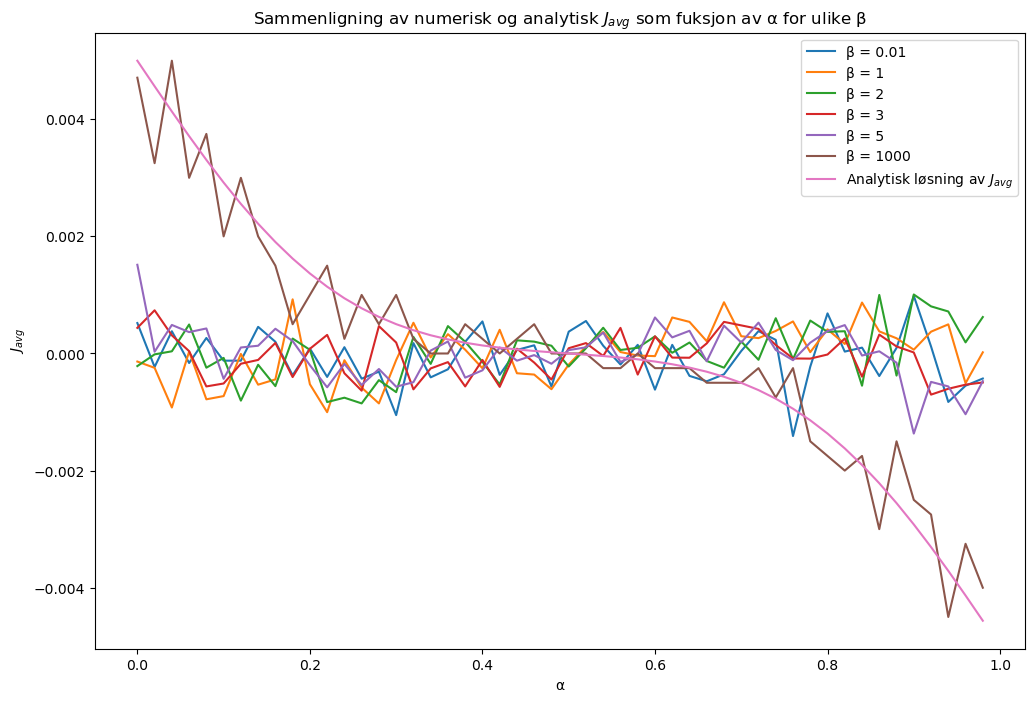

In [27]:
D = 1/3                                     # Diffusjonskoeffisient
T_p = 500                                   # Antall tidssteg i en tidssyklus
N_x_analytic = 100                          # Lengde på den romlige perioden til sagtann-potensialet
N_x = 10                                    
alphaArray = np.arange(0, 1, 1/50)          # Liste med jevnt fordelte alfa-verdier
BetaList = [0.01, 1, 2, 3, 5, 1000]         # Liste med beta-verdier gitt i oppgaven
number_of_particles = 4*N_x
timeCycle = 1
h = N_x/100                                 # Steglengde

integers = np.arange(-N_x, N_x, N_x)
x_start = np.array([i for i in integers for _ in range(int(number_of_particles/2))])    # Array med startposisjonene til partiklene

for b in BetaList:                          # Itererer gjennom betaverdiene
    beta = b
    J_avg_all_alpha2 = []
    for alphaValue in alphaArray:           # Itererer gjennom alfaverdiene
        x4, X4, X_cycle4, J4, J_avg4 = sim2(T_p, N_x, x_start, alphaValue)              # Simulerer for gitt alfaverdi og gitt betaverdi
        J_avg_all_alpha2.append(J_avg4[0])                                              # Fyller liste med J_avg

    plt.plot(alphaArray, J_avg_all_alpha2, label = f"β = {beta}")                       # Plotter J_avg for gitt beta

J_avg_analytic3 = []
for alphaValue in alphaArray:
    J_avg_analytic3.append(J_avg(alphaValue, T_p, N_x_analytic))                        # Finner analytisk J_avg ved ulike alfa


plt.plot(alphaArray, N_x/N_x_analytic *np.array(J_avg_analytic3), label = "Analytisk løsning av $J_{avg}$")
plt.title('Sammenligning av numerisk og analytisk $J_{avg}$ som fuksjon av α for ulike β')
plt.xlabel('α')
plt.ylabel('$J_{avg}$')
plt.legend()
plt.show()

kommentar til grafen over 

# d)

(Skriv inn oppgave d)